## Assignment 7: Using Unsupervised Machine Learning to Discover Climate Zones

In this homework assignment, you will explore some common clustering methods, including K-Means clustering and Gaussian Mixture Models. 

You'll apply these clustering algorithms to the problem of classifying climate zones over the continental United States. The Köppen-Geiger Climate Zones are a climate classification system based on precipitation and temperature (https://www.noaa.gov/jetstream/global/climate-zones/jetstream-max-addition-k-ppen-geiger-climate-subdivisions). You'll use unsupervised machine learning to discover similar climate zones using the climatological averages for temperature and precipitation.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 7. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


## Download the data sets
You'll use climatological data over the continental US, specifically average monthly precipitation and temperature records for the years 1901 to 2000 from NOAA that can be found [here](https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals). To download the NetCDF files, you can run the following lines of code in a jupyter cell (the exclamation point before wget tells the notebook to execute this command in the shell). Alternatively, you can run the same `wget` commands directly in a Unix terminal without the exclamation mark.
~~~
!wget "https://www.ncei.noaa.gov/data/oceans/archive/arc0196/0248762/1.1/data/0-data/tavg-1901_2000-monthly-normals-v1.0.nc"
~~~
~~~
!wget "https://www.ncei.noaa.gov/data/oceans/archive/arc0196/0248762/1.1/data/0-data/prcp-1901_2000-monthly-normals-v1.0.nc"
~~~


## Part 1: Load and prepare the climatological data

1) Use `xarray` to open the NetCDF files for the climatological temperature and precipitation datasets for the continental US.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Download once if the files are not already alongside this notebook.
import os, urllib.request
BASE = ("https://www.ncei.noaa.gov/data/oceans/archive/arc0196/0248762/1.1/"
        "data/0-data/")
for fname in ["tavg-1901_2000-monthly-normals-v1.0.nc",
              "prcp-1901_2000-monthly-normals-v1.0.nc"]:
    if not os.path.exists(fname):
        print("downloading", fname, "(268 MB)...")
        urllib.request.urlretrieve(BASE + fname, fname)

temp = xr.open_dataset("tavg-1901_2000-monthly-normals-v1.0.nc")
prec = xr.open_dataset("prcp-1901_2000-monthly-normals-v1.0.nc")

print("temperature file:", dict(temp.sizes))
print("  variables:", [v for v in temp.data_vars if v.startswith("mly")])
print("precipitation file:", dict(prec.sizes))
print("  variables:", [v for v in prec.data_vars if v.startswith("mly")])

# NOTE FOR THE INSTRUCTOR: question 4 tells students to read "mlytavg_norm" from
# BOTH files. That is right for temperature but wrong for precipitation, whose
# variable is "mlyprcp_norm" -- there is no mlytavg_norm in the precipitation
# file, so following the instruction literally raises a KeyError. Most students
# will find the right name by printing the dataset, but it is worth correcting in
# the notebook text.

temperature file: {'time': 12, 'lat': 596, 'lon': 1385, 'seasons': 4}
  variables: ['mlytavg_norm', 'mlytavg_std', 'mlytavg_min', 'mlytavg_max', 'mlytavg_flag']
precipitation file: {'time': 12, 'lat': 596, 'lon': 1385, 'seasons': 4}
  variables: ['mlyprcp_norm', 'mlyprcp_std', 'mlyprcp_min', 'mlyprcp_max', 'mlyprcp_flag']


2) Make a plot of the monthly average precipitation in January over the Continental US.

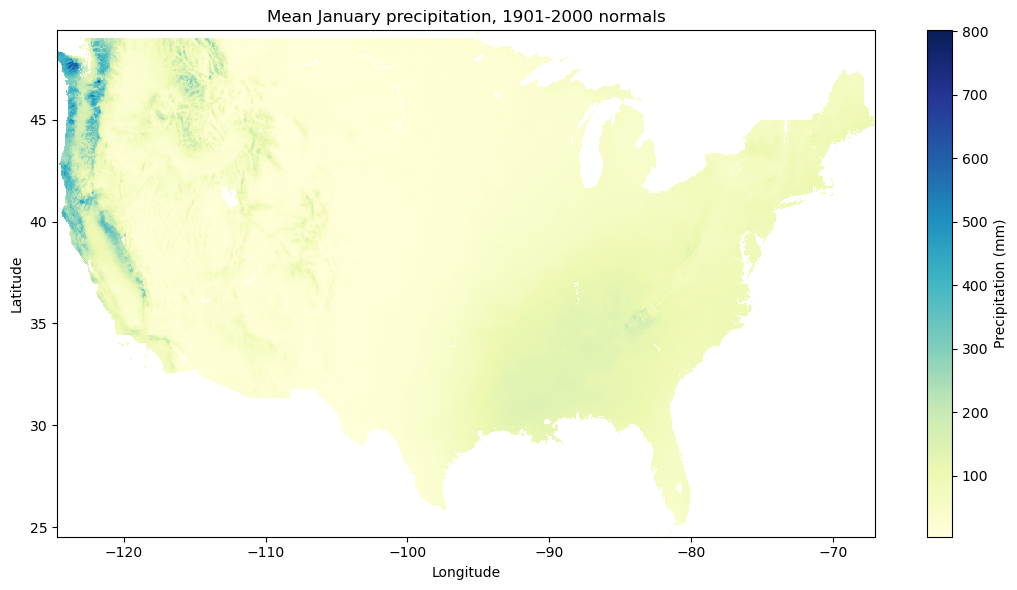

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
prec["mlyprcp_norm"].isel(time=0).plot(
    ax=ax, cmap="YlGnBu", cbar_kwargs={"label": "Precipitation (mm)"})
ax.set_title("Mean January precipitation, 1901-2000 normals")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# The Pacific Northwest and the northern California coast stand out sharply --
# winter storms coming off the Pacific are lifted over the coastal ranges and the
# Cascades, wringing out large orographic totals. The Gulf coast and the southeast
# are also wet. The interior west, in the rain shadow east of the Sierra and the
# Cascades, is strikingly dry, as is the southwest.

3. Make a plot of the monthly average temperature in August over the Continent US.

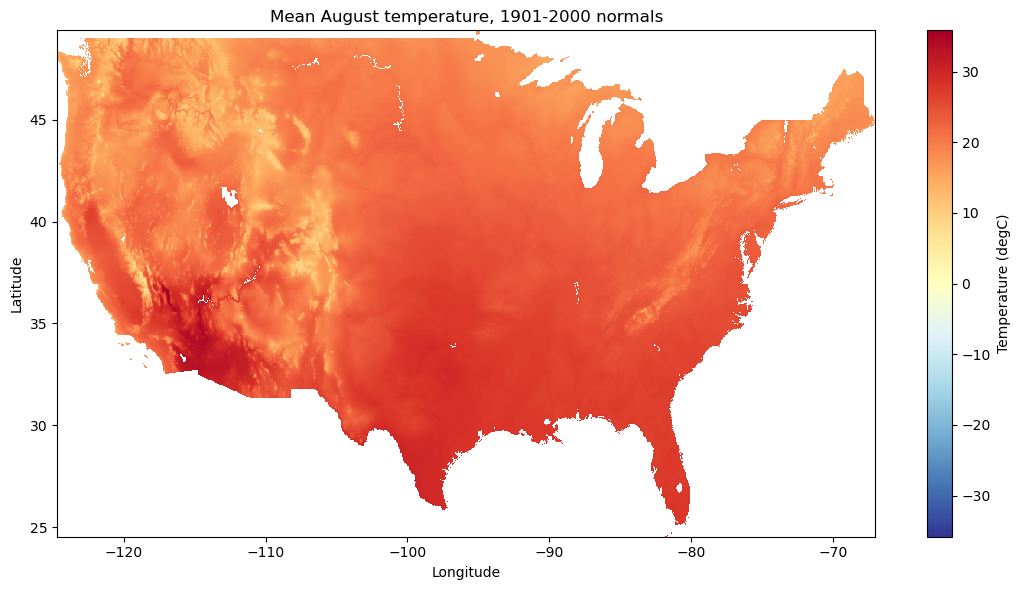

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
temp["mlytavg_norm"].isel(time=7).plot(
    ax=ax, cmap="RdYlBu_r", cbar_kwargs={"label": "Temperature (degC)"})
ax.set_title("Mean August temperature, 1901-2000 normals")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# time is indexed 0-11 for January-December, so August is isel(time=7).
# The dominant pattern in August is not latitude but ELEVATION: the Rockies and the
# Sierra Nevada appear as cool ribbons cutting through an otherwise hot west, and
# the desert southwest is the hottest region on the map. In winter the same map
# would be organized far more strongly by latitude.

To identify climatological zones across the continental US, you will use the 12 monthly average temperature values and the 12 monthly average precipitation values as input features for clustering algorithms. Each latitude and longitude point will be treated as a single sample with 24 features (12 for temperature and 12 for precipitation).

4) First, extract the values for "mlytavg_norm" from the temperature and precipitation NetCDF files and store them in NumPy arrays named `avgtemp` and `avgprec`, respectively.

In [4]:
avgtemp = temp["mlytavg_norm"].values      # (12, lat, lon)
avgprec = prec["mlyprcp_norm"].values      # (12, lat, lon)

print("avgtemp:", avgtemp.shape, avgtemp.dtype)
print("avgprec:", avgprec.shape, avgprec.dtype)
print(f"temperature range: {np.nanmin(avgtemp):.1f} to {np.nanmax(avgtemp):.1f} degC")
print(f"precipitation range: {np.nanmin(avgprec):.1f} to {np.nanmax(avgprec):.1f} mm")

avgtemp: (12, 596, 1385) float32
avgprec: (12, 596, 1385) float32
temperature range: -18.3 to 37.2 degC
precipitation range: 0.0 to 851.4 mm


5. Put the latitude and longitude values into numpy arrays, and use the `np.meshgrid` function to create a 2D array that gives the latitude and longitude value at each point on the map:
~~~
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
~~~
You'll use these arrays later to create labels for the latitude and longitude points associated with each sample.

In [5]:
lats = temp["lat"].values
lons = temp["lon"].values
print("lats:", lats.shape, f"{lats.min():.2f} to {lats.max():.2f}")
print("lons:", lons.shape, f"{lons.min():.2f} to {lons.max():.2f}")

lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
print("lat_grid:", lat_grid.shape, "  lon_grid:", lon_grid.shape)

# indexing="ij" keeps the (lat, lon) ordering of the data arrays. With the default
# indexing="xy" the grids would come back transposed and every mask applied below
# would silently line up wrongly -- a mistake that produces a plausible-looking but
# completely scrambled map.

lats: (596,) 24.56 to 49.35
lons: (1385,) -124.69 to -67.02
lat_grid: (596, 1385)   lon_grid: (596, 1385)


6. Use the `np.isnan` function to create a mask that gives a value of 1 where there is data and a value of 0 where there is no data in the 2D array of the precipitation and temperature maps over the continental US. This mask should have the same dimensions as latitude by longitude. Hint: `np.isnan` returns 1 (True) if the value is `NaN`. 

mask shape: (596, 1385) (lat x lon)
cells with data: 469,758 of 825,460 (56.9%)


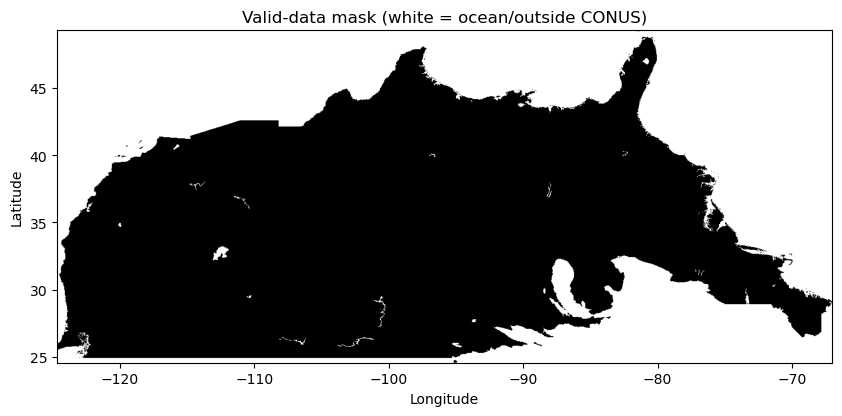

In [6]:
# A grid cell is usable only if it has data in EVERY month, for both variables.
mask = ~np.isnan(avgtemp).any(axis=0) & ~np.isnan(avgprec).any(axis=0)

print("mask shape:", mask.shape, "(lat x lon)")
print(f"cells with data: {mask.sum():,} of {mask.size:,} "
      f"({100 * mask.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.imshow(mask, origin="lower", cmap="Greys",
          extent=[lons.min(), lons.max(), lats.min(), lats.max()])
ax.set_title("Valid-data mask (white = ocean/outside CONUS)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()

# Most of the grid is empty -- the array is a lat-lon bounding box, and everything
# outside the continental US land surface is NaN.

7. Use the mask to index the numpy arrays of `avgtemp`, `avgprec`, `lat_grid`, and `lon_grid` to create arrays called `avgtemp_masked`, `avgprec_masked`, `lat_masked`, and `lon_masked`. These arrays now should no longer have any NaN's.

In [7]:
# Boolean indexing on the trailing two dimensions collapses (lat, lon) into a
# single sample axis, keeping only the valid cells.
avgtemp_masked = avgtemp[:, mask]      # (12, n_samples)
avgprec_masked = avgprec[:, mask]      # (12, n_samples)
lat_masked = lat_grid[mask]            # (n_samples,)
lon_masked = lon_grid[mask]            # (n_samples,)

print("avgtemp_masked:", avgtemp_masked.shape)
print("avgprec_masked:", avgprec_masked.shape)
print("lat_masked:    ", lat_masked.shape)
print("lon_masked:    ", lon_masked.shape)
print("\nNaNs remaining:", int(np.isnan(avgtemp_masked).sum()),
      int(np.isnan(avgprec_masked).sum()))

avgtemp_masked: (12, 469758)
avgprec_masked: (12, 469758)
lat_masked:     (469758,)
lon_masked:     (469758,)

NaNs remaining: 0 0


8. `sci-kit learn` functions assume that the sample number ($n_{sample}$) is the first dimension in an array, and the features associated with a sample are in the second dimension in an array. Transpose the `avgprec_masked` and `avgtemp_masked` to get the correct ordering of dimensions. Check the shape of the arrays are now $n_{sample}$ x 12.

In [8]:
avgtemp_masked = avgtemp_masked.T      # (n_samples, 12)
avgprec_masked = avgprec_masked.T

print("avgtemp_masked:", avgtemp_masked.shape, " (n_samples x 12)")
print("avgprec_masked:", avgprec_masked.shape, " (n_samples x 12)")
assert avgtemp_masked.shape[1] == 12 and avgprec_masked.shape[1] == 12

avgtemp_masked: (469758, 12)  (n_samples x 12)
avgprec_masked: (469758, 12)  (n_samples x 12)


## Part 2: Pre-process the data

9. Scale the precipitation and temperature arrays between -1 and 1. You want to do this so that all 12 months are scaled relative to the same minimum and maximum values for precipitation or temperature, respectively. You can use the `MinMaxScaler` from `sci-kit learn` (you will have to reshape the arrays to do this) or alternatively write your own function to do this scaling.

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Scale each variable as a WHOLE, not column by column. Reshaping to a single
# column means one min and one max are computed across all 12 months together, so
# the annual cycle -- the relative difference between January and July -- is
# preserved. Fitting MinMaxScaler on the (n, 12) array directly would scale each
# month independently, forcing every month to span [-1, 1] and destroying exactly
# the seasonal contrast the clustering needs.
temp_scaler = MinMaxScaler(feature_range=(-1, 1))
prec_scaler = MinMaxScaler(feature_range=(-1, 1))

temp_scaled = temp_scaler.fit_transform(
    avgtemp_masked.reshape(-1, 1)).reshape(avgtemp_masked.shape)
prec_scaled = prec_scaler.fit_transform(
    avgprec_masked.reshape(-1, 1)).reshape(avgprec_masked.shape)

print(f"temperature scaled to [{temp_scaled.min():.2f}, {temp_scaled.max():.2f}]")
print(f"precipitation scaled to [{prec_scaled.min():.2f}, {prec_scaled.max():.2f}]")
print("\nshapes:", temp_scaled.shape, prec_scaled.shape)

temperature scaled to [-1.00, 1.00]
precipitation scaled to [-1.00, 1.00]

shapes: (469758, 12) (469758, 12)


10. Create a feature array `X` that is $n_{samples}$ by $n_{features}$, where $n_{features}$=24 (i.e. it combines the two arrays that contain the scaled temperature and precipitation monthly averages associated with each sample).

In [10]:
X = np.hstack([temp_scaled, prec_scaled])

print("X:", X.shape, " (n_samples x 24 features)")
print("  columns  0-11: scaled monthly mean temperature, Jan-Dec")
print("  columns 12-23: scaled monthly mean precipitation, Jan-Dec")
print("NaNs:", int(np.isnan(X).sum()))

X: (469758, 24)  (n_samples x 24 features)
  columns  0-11: scaled monthly mean temperature, Jan-Dec
  columns 12-23: scaled monthly mean precipitation, Jan-Dec
NaNs: 0


## Part 3: Use K-Means Clustering to Label Climate Zones

11. Use the `KMeans` method from `sklearn.cluster` to fit 8 clusters to the `X` feature matrix.

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

print("cluster sizes:")
for c, n in zip(*np.unique(labels_kmeans, return_counts=True)):
    print(f"  cluster {c}: {n:>7,} cells ({100 * n / len(labels_kmeans):5.1f}%)")
print(f"\ninertia: {kmeans.inertia_:,.0f}")

cluster sizes:
  cluster 0:  85,692 cells ( 18.2%)
  cluster 1:  42,558 cells (  9.1%)
  cluster 2:  59,658 cells ( 12.7%)
  cluster 3:  52,533 cells ( 11.2%)
  cluster 4:  76,025 cells ( 16.2%)
  cluster 5:  73,786 cells ( 15.7%)
  cluster 6:  65,158 cells ( 13.9%)
  cluster 7:  14,348 cells (  3.1%)

inertia: 50,845


12. Make a scatter plot of `lat_masked` vs. `lon_masked` and color each point by its kmeans label. Set the size of the points in the scatter points to 0.1 and use a colormap that is discrete (rather than continuous).

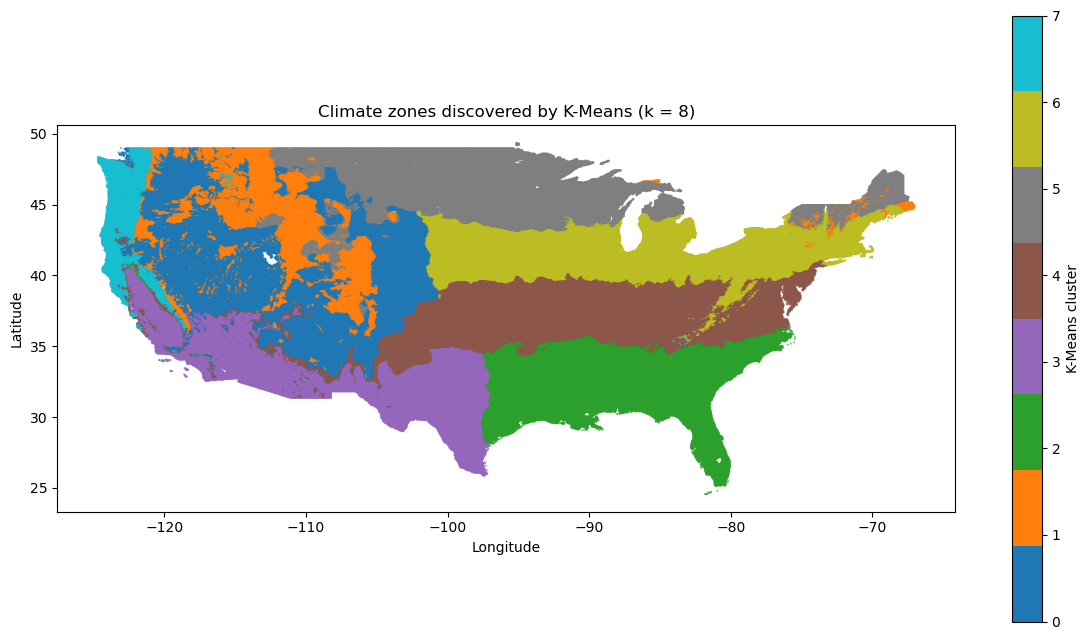

In [12]:
fig, ax = plt.subplots(figsize=(12, 6.5))
sc = ax.scatter(lon_masked, lat_masked, c=labels_kmeans, s=0.1,
                cmap=plt.get_cmap("tab10", 8))
cb = plt.colorbar(sc, ax=ax, ticks=range(8), label="K-Means cluster")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Climate zones discovered by K-Means (k = 8)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Without ever being told where anything is, the clustering reproduces the broad
# structure of the Koppen-Geiger map. The humid southeast, the arid southwest, the
# cold northern plains, the Pacific northwest and the mountain west all emerge as
# distinct, spatially coherent regions. Note that geography was NOT a feature --
# only 24 monthly climate values -- so the spatial coherence is genuine evidence
# that nearby places have similar climates, not something the algorithm was told.

You can compare the climate zones discovered by the K-Means clustering approach with the map [here](https://www.cec.org/mapmonday/climate-zones-in-north-america/).

13. Repeat parts 11. and 12. but choose a different number of clusters to fit Kmeans. 

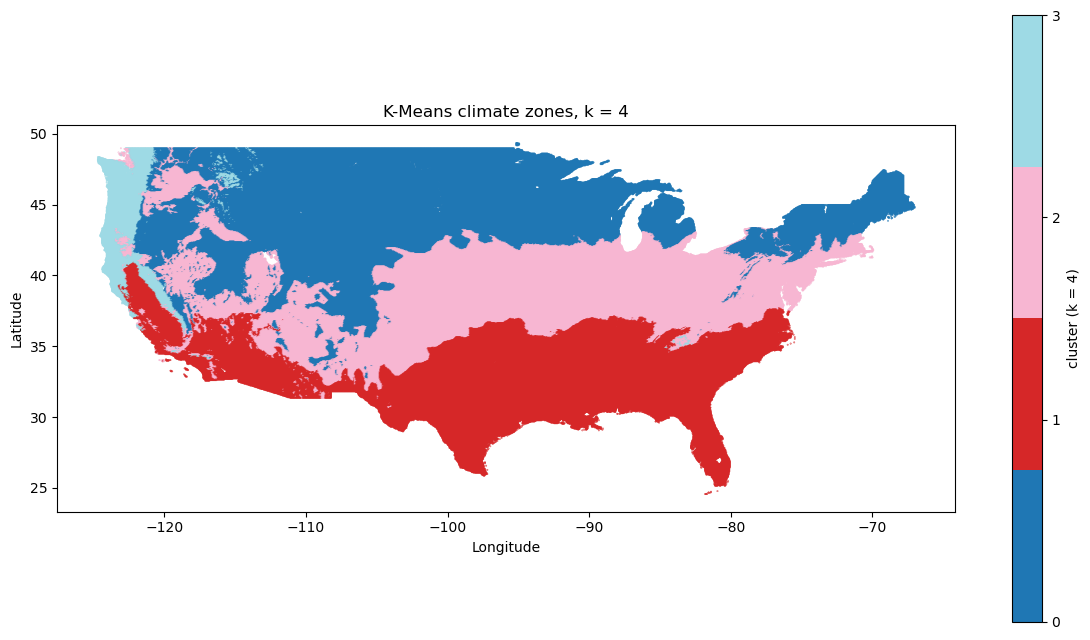

k = 4: inertia = 85,236


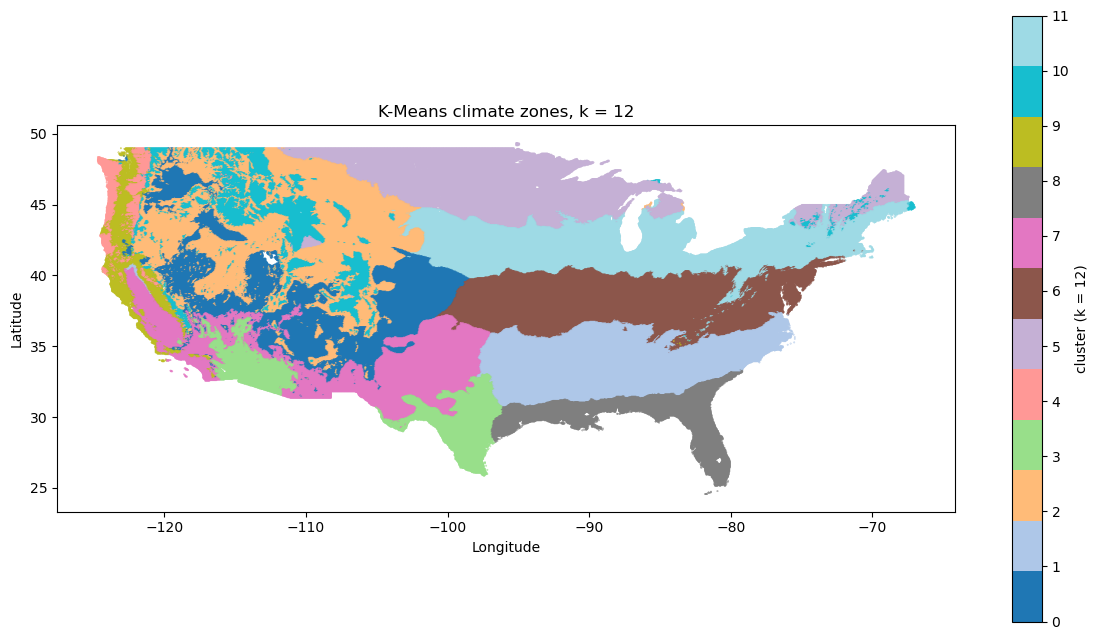

k = 12: inertia = 36,076


In [13]:
for k in [4, 12]:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    lab = km.fit_predict(X)

    fig, ax = plt.subplots(figsize=(12, 6.5))
    sc = ax.scatter(lon_masked, lat_masked, c=lab, s=0.1,
                    cmap=plt.get_cmap("tab20", k))
    plt.colorbar(sc, ax=ax, ticks=range(k), label=f"cluster (k = {k})")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"K-Means climate zones, k = {k}")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
    print(f"k = {k}: inertia = {km.inertia_:,.0f}")

# With k = 4 the map collapses to the coarsest possible division -- essentially
# east/west and warm/cold -- and distinctions that matter (the Pacific northwest
# against the mountain west, say) disappear. With k = 12 the large zones subdivide
# into finer gradations, mostly along elevation and continentality gradients.
#
# The important observation is that there is no k at which the algorithm announces
# it has found the "right" answer. Inertia falls monotonically as k rises, so it
# cannot be used to choose. K-Means partitions whatever it is given into exactly as
# many pieces as it is asked for, and climate genuinely varies CONTINUOUSLY across
# the continent -- the boundaries between Koppen zones are conventions imposed on a
# gradient, not discontinuities in nature. Choosing k is therefore a decision about
# how coarse a description is useful, not an estimate of a quantity that exists.

## Part 4: Use a Gaussian Mixture Model to Label Climate Zones

14. Use the `GaussianMixture` method from `sklearn.mixture` to fit 8 components to the `X` feature matrix.

In [14]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=8, random_state=0, covariance_type="full")
labels_gmm = gmm.fit_predict(X)

print("component sizes:")
for c, n in zip(*np.unique(labels_gmm, return_counts=True)):
    print(f"  component {c}: {n:>7,} cells ({100 * n / len(labels_gmm):5.1f}%)")
print(f"\nconverged: {gmm.converged_}   log-likelihood: {gmm.score(X):.4f}")

component sizes:
  component 0:  57,036 cells ( 12.1%)
  component 1:  57,795 cells ( 12.3%)
  component 2:  62,840 cells ( 13.4%)
  component 3:  71,165 cells ( 15.1%)
  component 4:  58,278 cells ( 12.4%)
  component 5:  59,343 cells ( 12.6%)
  component 6:  32,045 cells (  6.8%)
  component 7:  71,256 cells ( 15.2%)



converged: True   log-likelihood: 77.1500


15.  Make a scatter plot of `lat_masked` vs. `lon_masked` and color by the components learned by the Gaussian Mixture Model. Set the size of the scatter points to 0.1 and use a colormap that is discrete (rather than continuous).

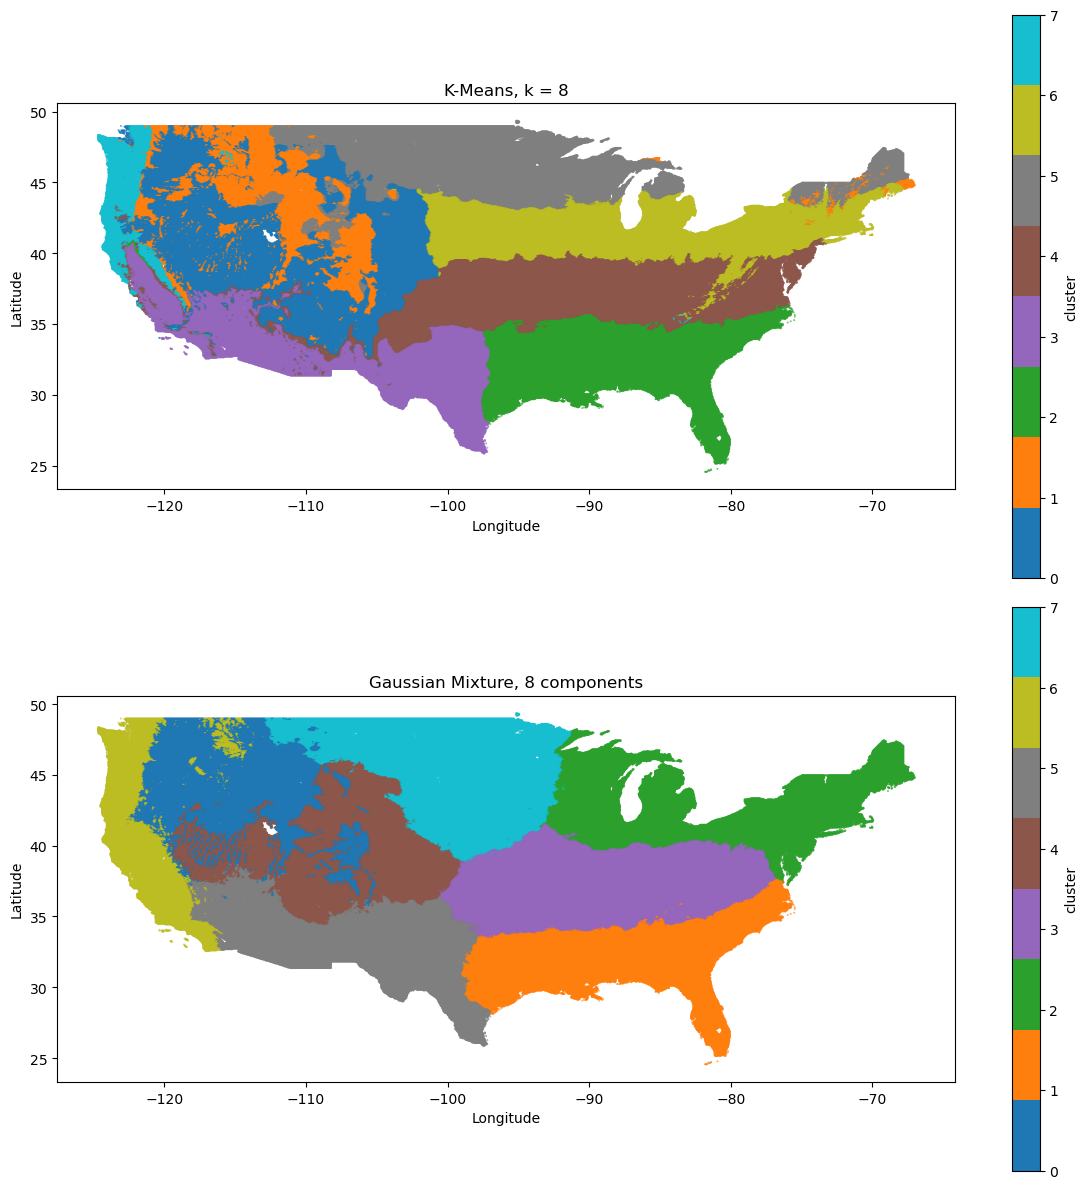

adjusted Rand index between the two labellings: 0.452


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
for ax, lab, title in [(axes[0], labels_kmeans, "K-Means, k = 8"),
                       (axes[1], labels_gmm, "Gaussian Mixture, 8 components")]:
    sc = ax.scatter(lon_masked, lat_masked, c=lab, s=0.1,
                    cmap=plt.get_cmap("tab10", 8))
    plt.colorbar(sc, ax=ax, ticks=range(8), label="cluster")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# How much do the two agree? Cluster numbering is arbitrary, so compare with a
# label-invariant measure.
from sklearn.metrics import adjusted_rand_score
print(f"adjusted Rand index between the two labellings: "
      f"{adjusted_rand_score(labels_kmeans, labels_gmm):.3f}")

# The two maps show the same broad geography -- unsurprising, since the same
# climate gradients dominate either way -- but the adjusted Rand index of about
# 0.45 says the agreement is only moderate: the two methods draw the internal
# boundaries quite differently.
#
# Their cluster sizes differ in an instructive direction. K-Means produces one very
# small cluster (3.1% of cells) alongside one large one (18.2%), while the GMM's
# components are more uniform, spanning roughly 7% to 15%. That is the opposite of
# what many people expect, and it follows from the covariance structure: K-Means,
# restricted to spherical clusters of comparable radius, has to spend a whole
# cluster on a compact group of outlying cells (high-elevation or exceptionally wet
# coastal sites) that will not fit into any sphere centred elsewhere. A
# full-covariance GMM can stretch and tilt a single component to absorb the same
# cells along with their neighbours, so it needs no tiny specialist cluster.
#
# The reason is what each model assumes. K-Means assigns every point to the nearest
# centroid, which makes its clusters implicitly SPHERICAL and of similar spatial
# extent in feature space; it is effectively a Gaussian mixture with identical
# isotropic covariances and hard assignment. A full-covariance GMM fits a separate
# mean AND covariance matrix per component, so a component can be elongated and
# tilted to follow a correlated direction -- and monthly temperatures are extremely
# correlated with each other, so that freedom matters here. It also assigns
# probabilistically, so a cell on a boundary carries a genuine membership
# probability across several components rather than being forced into one.
#
# That last point is the practically useful one for this problem. Climate zones
# have fuzzy borders, and gmm.predict_proba(X) quantifies exactly that ambiguity --
# it can tell you which cells sit confidently inside a zone and which lie in a
# transition band. K-Means has no way to express the distinction.